# Load Packages and Data

We are using data from UC Irvine Machine Learning Repository. The data is aimed at the case of customer's default payments in Taiwan and compared the predictive accuracy of probability.

In [27]:
from ucimlrepo import fetch_ucirepo
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn 

In [28]:
dataset = fetch_ucirepo(id=350)

X = dataset.data.features
y = dataset.data.targets

print(type(X))
print(type(y))
print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(30000, 23)
(30000, 1)


In [29]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [30]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [31]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

We note that the columns are arbitrarily named, so we rename them using their definitions as found on the website.

In [32]:
column_mapping = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
}

X = X.rename(columns=column_mapping)
y = y.rename(columns={"Y": "DEFAULT"})
print(X.columns.tolist())
print(y.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
['DEFAULT']


## Check Data Quality Issues

In [34]:
credit_data = pd.concat([X,y], axis=1) # join data with its target to analyse
credit_data['EDUCATION'].value_counts()


EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

We note that Education has numbers 0, 5, 6 which are not described by the data set. We want to explore what these other values are in order to decide what should be done with them.

In [33]:
credit_data.groupby('EDUCATION')['DEFAULT'].mean().sort_values(ascending=False)

EDUCATION
3    0.251576
2    0.237349
1    0.192348
6    0.156863
5    0.064286
4    0.056911
0    0.000000
Name: DEFAULT, dtype: float64

From this we see that each category (0, 5 and 6) behave differently and can therefore not be grouped with any other categories. If we keep these categories the model may learn a false pattern from an undocumented category. This can be seen even more in EDUCATION=0, which has a 0% default rate. These rows will be dropped. 


In [9]:
credit_data['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Here we also note an undocumented category "0". Let's decide what to do with it in the same way.

In [15]:
credit_data.groupby('MARRIAGE')['DEFAULT'].mean().sort_values(ascending=False)

MARRIAGE
3    0.260062
1    0.234717
2    0.209283
0    0.092593
Name: DEFAULT, dtype: float64

We can't determine what this category represents, and it behaves differently from all documented categories, so keeping it risks the model learning a false pattern. 

In [11]:
credit_data['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

Values are all good here (1= male, 2=female).

Now, we drop the rows which are in the undocumented categories. Let's check if there is any overlap between the two conditions first so we now how many rows we should be left with.

In [39]:
(credit_data['MARRIAGE'] == 0).sum() + credit_data['EDUCATION'].isin([0, 5, 6]).sum() 

np.int64(399)

All together, there are 399 instances of uncategorised items. Let's check these are unique cases or if they overlap. 

In [12]:
((credit_data['MARRIAGE'] == 0) & (credit_data['EDUCATION'].isin([0, 5, 6]))).sum()

np.int64(0)

There is 0 overlap between the two conditions. We now remove the rows using pandas negation.

In [24]:
df_clean = credit_data[~(credit_data['MARRIAGE'].isin([0])) & ~(credit_data['EDUCATION'].isin([0, 5, 6]))]

In [25]:
df_clean.shape

(29601, 24)

We had 30,000 rows to start and removed 399 so this shape makes sense. 

In [35]:
df_clean.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

I will now check for any missing data.

In [40]:
df_clean.isna().sum().sort_values(ascending=False)

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

There is no missing data so we can move on. 

# EDA 

1. What is the class balance of the target?
2. How do individual features relate to the target?
3. Are there outliers, and how extreme are they?


Start with checking the class balance as it gives the context to interpret everything else correctly. If we have high class imbalance, it would be hard to tell what is a meaningful patterns of an artefact of having very few defaulters. 

In [79]:
df_clean['DEFAULT'].describe()

count    29601.000000
mean         0.223134
std          0.416355
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEFAULT, dtype: float64

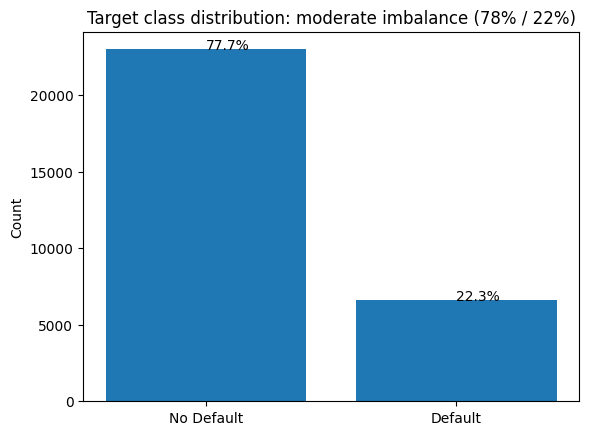

In [94]:
counts = df_clean['DEFAULT'].value_counts()
total = counts.sum()


plt.bar(counts.index, counts.values)
plt.title('Target class distribution: moderate imbalance (78% / 22%)')

plt.xticks([0, 1], ['No Default', 'Default'])

plt.ylabel('Count')

for i in range(len(counts.index)):
    plt.text(counts.index[i], counts.values[i], f"{counts.values[i] / total * 100:.1f}%")


There is an imbalance but it is only moderate. A dummy model would score around 78% accuracy. Recall is of high importance here as missing a true defaulter is more costly than wrongly flagging a non-defaulter. 